# Introduction


**File:** Notebook_to_build_graphics.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 10.03.2026
\
**Problem:** Here there are two:
 1) Plot $\psi(x)$
 2) Test our model for $M_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$

This code contains two short exercises. The first is just a sample of a run of our derivative grid code, which plots the IVP solutions for $\psi(x)$ The second is a short Monte Carlo test of our model for $M_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$, which contains both visual and numerical analysis.

# Derivative Grids

This is the code used for building the derivative grid graphs with the deriv_grid class of my library.

In [ ]:
#--LIBRARIES--------

#numerics
import numpy as np
import eelib

#--CODE--

# set parameters
# note that k, B, and R are percents here, mu is not as its scale is unknown
k = 0.625
R = 0.8
B = 0.5
mu = 1.0e-7

n_g = 4

pr = 1000
n = 2

loopl = eelib.deriv_grid(R, B, k, mu, grid_size=n_g)
loopl.derivGrid()


# --- PLOTTING FOR GRIDS ---
for i in range(n_g):
    for j in range(n_g):
        loopl.plot_abs(i,j,k,R,B,mu,n)
        loopl.plot_real(i,j,k,R,B,mu,n)

# Test of Slow Oscillation Wavenumber Model

This is code to visually and numerically test the fit of my slow oscillation model. The model is not perfect, but good enough.

In [1]:
import eelib
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as mtc
from sklearn.metrics import root_mean_squared_error

In [2]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-8

n_mc = 1000

b_r  = (0.5, 1.0)  # B here is B*R
mu_r = (-8, -6)    # 1.0e-8 to 1.0e-6
k_r = (0.1,0.9)


In [3]:
rms_ratio_graph = np.sqrt(1000) / np.sqrt(999)
rms_ratio_fin = np.sqrt(n_mc)/ np.sqrt(n_mc - 1)

In [4]:
#--CODE--

# Make the grid object
gridl = eelib.grid_slow_osc(R, B, dk, mu)

# Save our full solution
gridl.save_solution = True

# Make the grid
gridl.makeMCPoints(mu=mu_r, dk=k_r, B=b_r, num = n_mc)

# Run the grid
gridl.mcSlowOsc()

Begin grid build:  0.0
Number of periods to calculate: 1000
Done grid build:  44241.05874824524


In [5]:
import pickle
filename = 'grid202'

# Since this takes a while to run and is used for a while, it is best to save a copy of the data.
file = open(filename, 'ab')
pickle.dump(gridl, file)
file.close()

In [6]:
# First, declare which solution I am using
ii  = int(np.random.rand()*n_mc)
#if ii >= n_mc: ii = n_mc - 1 # just in case
sol = gridl.slow_osc_sol[ii]
#sol1 = gridl.slow_osc_sol_1[ii]

# Retrieve my fits for this function from the grid.
MM    = gridl.slow_osc_k[ii]
amp   = gridl.slow_osc_a[ii]
theta = gridl.slow_osc_th[ii]

# Predicted slow oscillation amplitude.
vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

# Pull the found solution from the sol variable.
t_list  = sol['t'][:-1]
y1_list = np.real(sol['y'][0][:-1])

# Estimated fit
y2_list = amp * np.sin(MM2 * (t_list) + theta)

# Fit to a sin using SciPy
y3_list = amp * np.sin(MM * t_list + theta)

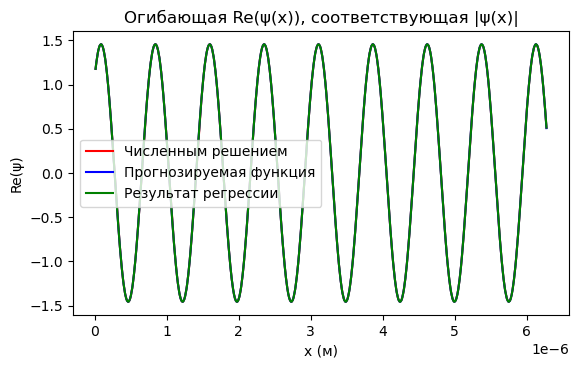

In [7]:
# And plot the results
fig, ax = plt.subplots()

ax.set_ylabel('Re(ψ)')
ax.set_xlabel('x (м)')
plt.title(f"Огибающая Re(ψ(x)), соответствующая |ψ(x)|")

line1, = ax.plot(t_list, y1_list, color = 'red', label = 'Численным решением')
line2, = ax.plot(t_list, y2_list, color = 'blue', label = 'Прогнозируемая функция')
line3, = ax.plot(t_list, y3_list, color = 'green', label = 'Результат регрессии')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.savefig("matchMivp007.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [8]:
print(root_mean_squared_error(y1_list, y2_list)/np.max(np.abs(y1_list)))
print(root_mean_squared_error(y1_list, y3_list)/np.max(np.abs(y1_list)))
print(root_mean_squared_error(y2_list, y3_list)/np.max(np.abs(y1_list)))

0.0011726119308023695
0.001106762644189752
0.001883326131880603


In [9]:
print(mtc.mean_absolute_percentage_error(y1_list, y2_list))
print(mtc.mean_absolute_percentage_error(y1_list, y3_list))
print(mtc.mean_absolute_percentage_error(y2_list, y3_list))

0.004894494858836061
0.0038946210249686257
0.006494427258946964


In [10]:
print(mtc.r2_score(y1_list, y2_list))
print(mtc.r2_score(y1_list, y3_list))
print(mtc.r2_score(y2_list, y3_list))
#print(mtc.mean_absolute_percentage_error(y1_list, y2_list))
#print(mtc.mean_absolute_percentage_error(y1_list, y3_list))
#print(mtc.mean_absolute_percentage_error(y2_list, y3_list))

0.9999972818447911
0.9999975785549448
0.9999929911008765


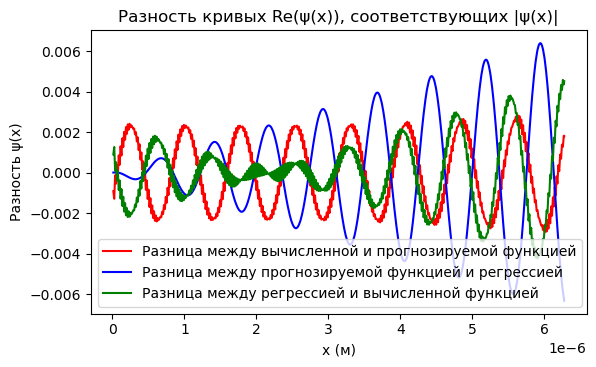

In [11]:
# Plot differences
fig, ax = plt.subplots()

ax.set_ylabel('Разность ψ(x)')
ax.set_xlabel('x (м)')
plt.title(f"Разность кривых Re(ψ(x)), соответствующих |ψ(x)|")

line1, = ax.plot(t_list, y1_list-y2_list, color = 'red', label = 'Разница между вычисленной и прогнозируемой функцией')
line2, = ax.plot(t_list, y2_list-y3_list, color = 'blue', label = 'Разница между прогнозируемой функцией и регрессией')
line3, = ax.plot(t_list, y3_list-y1_list, color = 'green', label = 'Разница между регрессией и вычисленной функцией')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.savefig("matchMivp008.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [12]:
np.abs(gridl.slow_osc_sol_1[ii]-gridl.slow_osc_sol[ii]['y'][0][-1])

0.0035165631633534106

In [13]:
res = []
for i in range(n_mc):
    res.append(gridl.slow_osc_sol[i]['y'][0][-1])

In [14]:
# Print the differences
print(f"Estimated slow oscillation wave number: {MM2}")
print(f"Fit slow oscillation wave number: {MM}")
print("Maximum difference between regression fit and predicted fit:", np.max(y3_list-y2_list))
print("Maximum difference between numerical solution and predicted fit:", np.max(y1_list-y2_list))
print("Maximum difference between numerical solution and regression fit:", np.max(y1_list-y3_list))

Estimated slow oscillation wave number: 8318455.349291266
Fit slow oscillation wave number: 8317714.5587974535
Maximum difference between regression fit and predicted fit: 0.006339458391062647
Maximum difference between numerical solution and predicted fit: 0.0028447657811975224
Maximum difference between numerical solution and regression fit: 0.0042338700850577116


In [15]:
# Now for the rest of the numbers
max_arr = np.zeros((n_mc,3))
ave_arr = np.zeros((n_mc,3))
std_arr = np.zeros((n_mc,3))
rmse_arr = np.zeros((n_mc,3))
mape_arr = np.zeros((n_mc,3))
r2_arr = np.zeros((n_mc,3))
arr_wn = np.zeros((n_mc,2))
arr_fp = np.zeros((n_mc,2), dtype="complex")
arr_max = np.zeros(n_mc)
for ii in range(n_mc):
    # First, declare which solution I am using
    sol = gridl.slow_osc_sol[ii]

    # Retrieve my fits for this function from the grid.
    MM    = gridl.slow_osc_k[ii]
    amp   = gridl.slow_osc_a[ii]
    theta = gridl.slow_osc_th[ii]

    # Predicted slow oscillation amplitude.
    vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
    MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

    arr_wn[ii] = [MM, MM2]

    # Pull the found solution from the sol variable.
    t_list  = sol['t'][:-1]
    y1_list = np.real(sol['y'][0][:-1])

    # Estimated fit
    y2_list = amp * np.sin(MM2 * (t_list) + theta)

    # Fit to a sin using SciPy
    y3_list = amp * np.sin(MM * t_list + theta)

    y_end = sol['y'][0][-1]
    arr_fp[ii] = [y_end, gridl.slow_osc_sol_1[ii]]
    arr_max[ii] = np.max(np.abs(y1_list))

    max_arr[ii, :] = [np.max(np.abs(y3_list-y2_list)), np.max(np.abs(y1_list-y2_list)), np.max(np.abs(y1_list-y3_list))]
    ave_arr[ii, :] = [np.average(y3_list-y2_list), np.average(y1_list-y2_list), np.average(y1_list-y3_list)]
    std_arr[ii, :] = [np.std(y3_list-y2_list), np.std(y1_list-y2_list), np.std(y1_list-y3_list)]
    rmse_arr[ii, :] = [mtc.root_mean_squared_error(y3_list,y2_list)/np.max(np.abs(y1_list)), mtc.root_mean_squared_error(y1_list,y2_list)/np.max(np.abs(y1_list)), mtc.root_mean_squared_error(y1_list,y3_list)/np.max(np.abs(y1_list))]
    mape_arr[ii, :] = [mtc.mean_absolute_percentage_error(y3_list,y2_list), mtc.mean_absolute_percentage_error(y1_list,y2_list), mtc.mean_absolute_percentage_error(y1_list,y3_list)]
    r2_arr[ii, :] = [mtc.r2_score(y3_list,y2_list), mtc.r2_score(y1_list,y2_list), mtc.r2_score(y1_list,y3_list)]

    # Print the differences
    print(f"Random solution {ii}")
    print(f"Estimated slow oscillation wave number: {MM2}")
    print(f"Fit slow oscillation wave number: {MM}")
    print("Maximum difference between regression fit and estimated fit:", max_arr[ii,0])
    print("Maximum difference between numerical solution and estimated fit:", max_arr[ii,1])
    print("Maximum difference between numerical solution and regression fit:", max_arr[ii,2])
    print("Average Diff: ", ave_arr[ii,:])
    print("Std: ", std_arr[ii,:])
    print("rmse: ", rmse_arr[ii,:])
    print("mape: ", mape_arr[ii,:])

    print("")

Random solution 0
Estimated slow oscillation wave number: 5917706.687752916
Fit slow oscillation wave number: 5917653.649904839
Maximum difference between regression fit and estimated fit: 0.0004610299065462651
Maximum difference between numerical solution and estimated fit: 0.001152654786960916
Maximum difference between numerical solution and regression fit: 0.001329831282981253
Average Diff:  [-1.22513781e-05 -1.35688653e-06  1.08944916e-05]
Std:  [0.00019671 0.00040504 0.00043649]
rmse:  [0.00013769 0.00028298 0.00030504]
mape:  [0.00064965 0.00056075 0.00072706]

Random solution 1
Estimated slow oscillation wave number: 6033935.60652884
Fit slow oscillation wave number: 6034038.329006669
Maximum difference between regression fit and estimated fit: 0.0008948925455543599
Maximum difference between numerical solution and estimated fit: 0.001352423785298873
Maximum difference between numerical solution and regression fit: 0.0012423248010491328
Average Diff:  [-2.44045661e-05 -1.699797

In [38]:
print("curve rel rmse", np.sqrt(np.average(np.power(rmse_arr[:,1]/arr_max, 2))*(1000*1000)/(1000*1000-1)))
print("curve rmse", np.sqrt(np.average(np.power(rmse_arr[:,1], 2))))
print("m rmse", mtc.root_mean_squared_error(arr_wn[:,0], arr_wn[:,1]))
print("m rel rmse", np.sqrt(1000/999)*np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0], 2))))
print("fin point rmse", np.sqrt(np.average(np.power(np.abs(arr_fp[:,0]-arr_fp[:,1]),2))))
print("fin point rel rmse", np.sqrt(np.sum(np.power(np.abs(arr_fp[:,0]-arr_fp[:,1]), 2))/999))
print("")
print("curve min r2", np.min(r2_arr[:,1]))
print("curve ave r2", np.average(r2_arr[:,1]))
print("m r2", mtc.r2_score(arr_wn[:,0], arr_wn[:,1]))
print("")
print("curve max", np.max(max_arr[:,1]))
print("curve rel max", np.max(max_arr[:,1]/arr_max))
print("m max", np.max(np.abs((arr_wn[:,0]-arr_wn[:,1]))))
print("m rel max", np.max(np.abs((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0])))
print("fin max", np.max(np.abs(arr_fp[:,0]-arr_fp[:,1])))
print("fin rel max", np.max(np.abs(arr_fp[:,0]-arr_fp[:,1])))
print("")
print("curve mean", np.average(ave_arr[:,1]))
print("curve std", np.sqrt(np.average(np.power(std_arr[:,1],2))))
print("m mean", np.average(arr_wn[:,0]-arr_wn[:,1]))
print("m std", np.std(arr_wn[:,0]-arr_wn[:,1]))
print("fin mean", np.average(arr_fp[:,0]-arr_fp[:,1]))
print("fin std", np.std(arr_fp[:,0]-arr_fp[:,1]))
print("")
print("curve mape", np.average(mape_arr[:,1]))
print("m mape", mtc.mean_absolute_percentage_error(arr_wn[:,0], arr_wn[:,1]))
print("fin mape", np.average(np.abs(arr_fp[:,0]-arr_fp[:,1])/np.abs(arr_fp[:,0])))

curve rel rmse 0.004575697792521872
curve rmse 0.0062200331096135585
m rmse 2126.7435437597464
m rel rmse 0.00037184533938023175
fin point rmse 0.011931019016763066
fin point rel rmse 0.011936989004135286

curve min r2 0.9815250115039694
curve ave r2 0.99992251125899
m r2 0.999997830627701

curve max 0.23123867291858272
curve rel max 0.13612921768819056
m max 31902.76509098988
m rel max 0.005954109036698583
fin max 0.1203866096967926
fin rel max 0.1203866096967926

curve mean -2.208220194987432e-05
curve std 0.008836129427541138
m mean 281.0138895660117
m std 2108.0961303495496
fin mean (-0.0003825734805237139+0.0001413423563623511j)
fin std 0.011924046068707544

curve mape 0.01701264684483553
m mape 0.00011622012240064124
fin mape 0.014661209364067106


In [16]:
np.sqrt(np.average(np.power(rmse_arr[:,1]/arr_max, 2))*(1000*200)/(1000*200-1))

0.004575706943954063

In [17]:
np.min(r2_arr[:,1])

0.9815250115039694

In [18]:
np.average(r2_arr[:,1])

0.99992251125899

In [19]:
print(np.max(max_arr[:,0]), np.max(mape_arr[:,0]), np.max(rmse_arr[:,0]))

0.3368146293733405 1.0718615657895447 0.08213929993784762


In [20]:
np.sqrt(np.average(np.power(rmse_arr[:,1], 2)))

0.0062200331096135585

In [21]:
np.average(mape_arr[:,0])

0.019013370024743907

In [22]:
print(np.max(max_arr[:,1]), np.max(mape_arr[:,1]), np.max(rmse_arr[:,1]))

0.23123867291858272 0.8028232811497711 0.09593929769628466


In [23]:
print(np.average(max_arr[:,1]), np.average(mape_arr[:,1]), np.average(rmse_arr[:,1]))

0.005230635844098788 0.01701264684483553 0.0020489295664157404


In [24]:
print(np.average(max_arr[:,0]), np.average(mape_arr[:,0]), np.average(rmse_arr[:,0]))

0.006427116168210523 0.019013370024743907 0.002027619429055328


In [25]:
np.sqrt(np.average(np.power(rmse_arr[:,1], 2))), np.sqrt(np.sum(np.power(rmse_arr[:,1], 2))/199)

(0.0062200331096135585, 0.01394331883462703)

In [26]:
mtc.root_mean_squared_error(arr_wn[:,0], arr_wn[:,1])

2126.7435437597464

In [27]:
mtc.mean_absolute_percentage_error(arr_wn[:,0], arr_wn[:,1])

0.00011622012240064124

In [28]:
np.max(np.abs((arr_wn[:,0]-arr_wn[:,1]))), np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0], 2)))#*np.sqrt(200)/np.sqrt(199)

(31902.76509098988, 0.00037165937020661936)

In [29]:
np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1]), 2)))

2126.7435437597464

In [30]:
np.max((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0])

0.005954109036698583

In [31]:
mtc.r2_score(arr_wn[:,0], arr_wn[:,1])

0.999997830627701

In [32]:
np.mean(arr_wn[:,0]-arr_wn[:,1]), np.std(arr_wn[:,0]-arr_wn[:,1])

(281.0138895660117, 2108.0961303495496)

In [33]:
arr_fp[:,0]

array([ 1.19483966-5.24546781e-01j, -1.38645953-1.66689141e-01j,
        1.30479037+3.72509151e-01j, -0.15532405+3.95539566e-02j,
       -0.56621639-8.57543280e-03j, -1.03894045-5.76551310e-01j,
       -0.57442338-7.41668864e-01j,  1.63007846+1.99160742e-01j,
       -0.94634465+7.21433172e-01j, -0.20978667-3.04553687e-01j,
       -0.44365476+5.71043305e-01j, -0.33590885+7.84900811e-01j,
        0.80669243+9.20210455e-01j,  0.05530158+7.33231216e-01j,
        0.59227572-5.36823468e-01j, -1.11221681-3.54704123e-01j,
        1.242283  -1.98050919e-01j,  0.00775464-5.29435413e-02j,
        0.77996333+2.08678594e-01j,  0.63610117-5.02821764e-01j,
        0.37049308+1.22490764e+00j,  0.01032422-1.04777229e+00j,
       -0.55824219+1.42814955e+00j,  0.46562623+3.32589052e-01j,
        0.52955   -2.00536517e-01j,  0.25184652-1.64658474e-01j,
        0.66856399-3.31514095e-01j,  0.31232362-5.96150075e-01j,
       -1.08761568+9.49315958e-01j, -1.07343956-1.24566117e+00j,
       -0.67766234-2.1080

In [34]:
np.sqrt(np.sum(np.power(np.abs(arr_fp[:,0]-arr_fp[:,1]), 2))/199)

0.026745517144531935

In [35]:
np.max(np.abs(arr_fp[:,0]-arr_fp[:,1]))

0.1203866096967926

In [36]:
np.std(arr_fp[:,0]-arr_fp[:,1])

0.011924046068707544